In [1]:
from classy import Class
import numpy as np
import matplotlib.pyplot as plt

In [2]:
Class?

Init signature: Class(self, /, *args, **kwargs)
Docstring:     
Class wrapping, creates the glue between C and python

The actual Class wrapping, the only class we will call from MontePython
(indeed the only one we will import, with the command:
from classy import Class
File:           ~/Install/anaconda3/lib/python3.11/site-packages/classy-3.2.3-py3.11-macosx-11.0-arm64.egg/classy.cpython-311-darwin.so
Type:           type
Subclasses:     

In [3]:
pk = np.zeros((20,100))
cl = np.zeros((20,2501))
cosmo={'omega_b':0.0223828,'omega_cdm':0.1201075,'h':0.67810,'A_s':2.100549e-09,'n_s':0.9660499,'tau_reio':0.05430842}
#for i,alphaK in enumerate(np.linspace(0.01,1.3,20)):
for i,alphaK in enumerate([1.,0.5,0.2,0.1]):
    print('{},0.,0.,0.,1.'.format(alphaK),i)
    M=Class()
    hiset={
        'Omega_smg':-1,
        'Omega_fld':0,
        'Omega_Lambda':0,
        'gravity_model':'propto_omega',
        'parameters_smg':'{},0.3,0.,0.,1.'.format(alphaK),
        #'parameters_smg':'0.,0.,0.,0.,1.',
        'expansion_model':'w0wa',
        'expansion_smg':'0.7,-0.8,0',
        # 'expansion_model':'lcdm',
        # 'expansion_smg':'0.7',
        'skip_stability_tests_smg':'n',
        # 'cs2_safe_smg':10.,
        #'D_safe_smg':1e-14,
        # 'ct2_safe_smg':10.,
        # 'M2_safe_smg':10.,
        'method_qs_smg':'automatic'
    }
    M.set(cosmo)
    M.set(hiset)
    M.set({'output':'tCl,mPk'})
    M.compute()
    k = np.logspace(-3,0,100)
    z=0.
    pk[i,:] = np.array([M.pk(ki,z) for ki in k])
    cl[i,:] = M.raw_cl()['tt']
    print(np.sum(M.get_background()['kineticity_smg'][:100]))

1.0,0.,0.,0.,1. 0
2.889656021586077e-42
0.5,0.,0.,0.,1. 1
2.889656021586077e-42
0.2,0.,0.,0.,1. 2
2.889656021586077e-42
0.1,0.,0.,0.,1. 3
2.889656021586077e-42


In [10]:
M.get_background()['c_s^2']

array([1., 1., 1., ..., 1., 1., 1.])

/var/folders/2x/rv34yy5954lf_chxzn0kbl440000gn/T/ipykernel_96357/1567032275.py:3: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  plt.loglog()


[]

/Users/zhiyulu/Install/anaconda3/lib/python3.11/site-packages/IPython/core/events.py:82: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  func(*args, **kwargs)


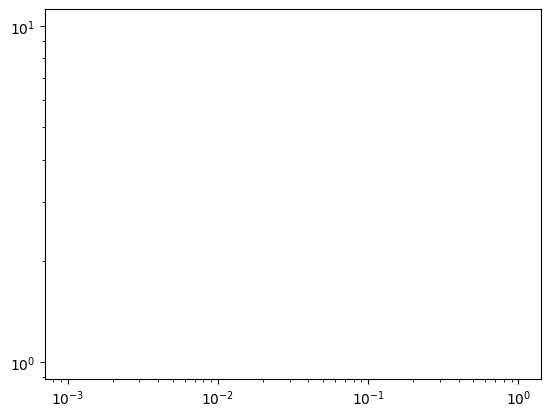

In [5]:
for i in range(4):
    plt.plot(k,np.abs(pk[i,:]/pk[0,:]-1))
plt.loglog()
#plt.xlim(1e-2,1)

[1. 1. 1. ... 1. 1. 1.]
[1. 1. 1. ... 1. 1. 1.]
[1. 1. 1. ... 1. 1. 1.]
[1. 1. 1. ... 1. 1. 1.]
[0. 0. 0. ... 0. 0. 0.]
[0. 0. 0. ... 0. 0. 0.]
[0. 0. 0. ... 0. 0. 0.]
[0. 0. 0. ... 0. 0. 0.]
[0. 0. 0. ... 0. 0. 0.]
[0. 0. 0. ... 0. 0. 0.]
[0. 0. 0. ... 0. 0. 0.]
[0. 0. 0. ... 0. 0. 0.]
[0. 0. 0. ... 0. 0. 0.]
[0. 0. 0. ... 0. 0. 0.]
[0. 0. 0. ... 0. 0. 0.]
[0. 0. 0. ... 0. 0. 0.]
[0. 0. 0. ... 0. 0. 0.]
[0. 0. 0. ... 0. 0. 0.]
[0. 0. 0. ... 0. 0. 0.]
[0. 0. 0. ... 0. 0. 0.]


[]

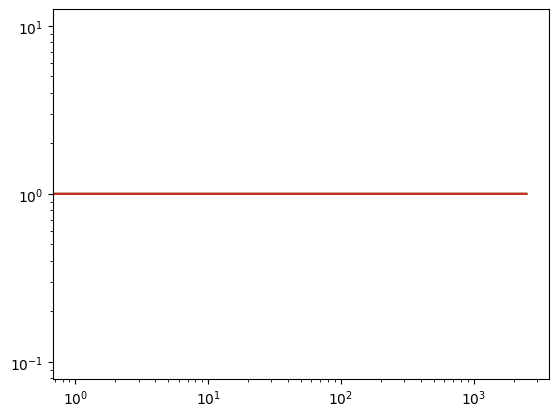

In [6]:
for i in range(20):
    print(cl[i,2:]/cl[0,2:])
    plt.plot(cl[i,2:]/cl[0,2:])
plt.loglog()

In [7]:
z = M.get_background()['z']
rho_smg=M.get_background()['(.)rho_smg']
rho_crit=M.get_background()['(.)rho_crit']
print(rho_smg[-1]/rho_crit[-1],'\n',M.get_background()['c_s^2'])

0.6900259954953076 
 [1. 1. 1. ... 1. 1. 1.]


In [8]:
k = np.logspace(-3,0,100)
z=0.
pk = np.array([M.pk(ki,z) for ki in k])
np.savetxt('hiclass_w-0.7.txt',pk)